&#x1f12f; Lucas Estevao Bazilio - Digitalització 1r DAM/CIDE/25-26

In [ ]:
# Descomentar para actualizar librerias
# Si se actualiza alguna libreria hay que reiniciar el notebook
#!pip install pandas --upgrade --user --quiet
#!pip install numpy --upgrade --user --quiet
#!pip install scipy --upgrade --user --quiet
#!pip install scikit-learn --upgrade --user --quiet
#!pip install missingno --upgrade --user --quiet
# versionesmodernas pero compatibles con Colab
#!pip install "pandas==2.2.2" "numpy<2.1.0" scipy scikit-learn missingno --upgrade --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.5 MB/s eta 0:00:00


In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
from sklearn import datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import pandas as pd

from sklearn import set_config
import warnings

set_config(display='text')
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)

from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE


# Ejercicio práctico de visualización

En este ejercicio trabajaremos con el conjunto de datos preprocesado en la primera sesion de laboratorio.

Encontraréis los datos preprocesados de Titanic entre el material de esta sesion (conjunto de entrenamiento), o podeis coger los datos que grabasteis en la sesión pasada.



Debéis aplicar los siguientes pasos:
- [ ] Aplicar PCA
- [ ] Gráfica de la varianza explicada por cada componente de PCA
- [ ] Representar los pesos de los componentes
- [ ] Visualizar los datos con PCA en 2/3D
- [ ] Aplicar LLE y visualizar los datos en 2/3D
- [ ] Aplicar t-SNE y visualizar los datos en 2/3D


**0. Preparación de datos**


In [3]:
# Importanción CSV desde drive
import io
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


Objetivo: separar los mas de 1000 individuos en 6 clases en una matríz 3x3 según su clase y si sobrevivió



In [5]:
titanic_data = pd.read_csv("titanic.csv", header=0)
#leemos los datos
#renombramos algunas columnas para mejorar la legibilidad
titanic_data = titanic_data.rename(columns={'pclass':'socialClass', 'sibsp':'number of siblings', 'home.dest':'destination',})

#mapeamos los datos segun clase social y si sobrevivió
titanic_data['socialClass'] = titanic_data['socialClass'].map({1:'First', 2:'Second', 3:'Third'})
titanic_data['survived'] = titanic_data['survived'].map({1:'Yes', 0:'No'})

#mostramos los datos
titanic_data.describe(include='all')
titanic_data.head()

,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
count,1309,1309,1309,1309,1046.000,1309.000,1309.000,1309,1308.000,295,1307,486,121.000,745
unique,3,2,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,Third,No,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,709,809,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,NaN,NaN,NaN,NaN,29.881,0.499,0.385,NaN,33.295,NaN,NaN,NaN,160.810,NaN
std,NaN,NaN,NaN,NaN,14.413,1.042,0.866,NaN,51.759,NaN,NaN,NaN,97.697,NaN
min,NaN,NaN,NaN,NaN,0.167,0.000,0.000,NaN,0.000,NaN,NaN,NaN,1.000,NaN
25%,NaN,NaN,NaN,NaN,21.000,0.000,0.000,NaN,7.896,NaN,NaN,NaN,72.000,NaN
50%,NaN,NaN,NaN,NaN,28.000,0.000,0.000,NaN,14.454,NaN,NaN,NaN,155.000,NaN
75%,NaN,NaN,NaN,NaN,39.000,1.000,0.000,NaN,31.275,NaN,NaN,NaN,256.000,NaN


,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
0,First,Yes,"Allen, Miss. Elisabeth Walton",female,29.000,0,0,24160,211.338,B5,S,2,NaN,"St Louis, MO"
1,First,Yes,"Allison, Master. Hudson Trevor",male,0.917,1,2,113781,151.550,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,First,No,"Allison, Miss. Helen Loraine",female,2.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,First,No,"Allison, Mr. Hudson Joshua Creighton",male,30.000,1,2,113781,151.550,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,First,No,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [6]:
#definimos una columna igual a la clase social + si ha sobrevivido
titanic_data['class'] =  titanic_data.socialClass + " " + titanic_data.survived
# segunda columna gual al valor total + ordenador
titanic_data['class'].value_counts().sort_index()

,count
class,
First No,123
First Yes,200
Second No,158
Second Yes,119
Third No,528
Third Yes,181


<Axes: xlabel='value', ylabel='variable'>

<Axes: xlabel='value', ylabel='variable'>

Text(0.5, 1.0, 'Distribución de Edad y Tarifa por Clase Social y Supervivencia')

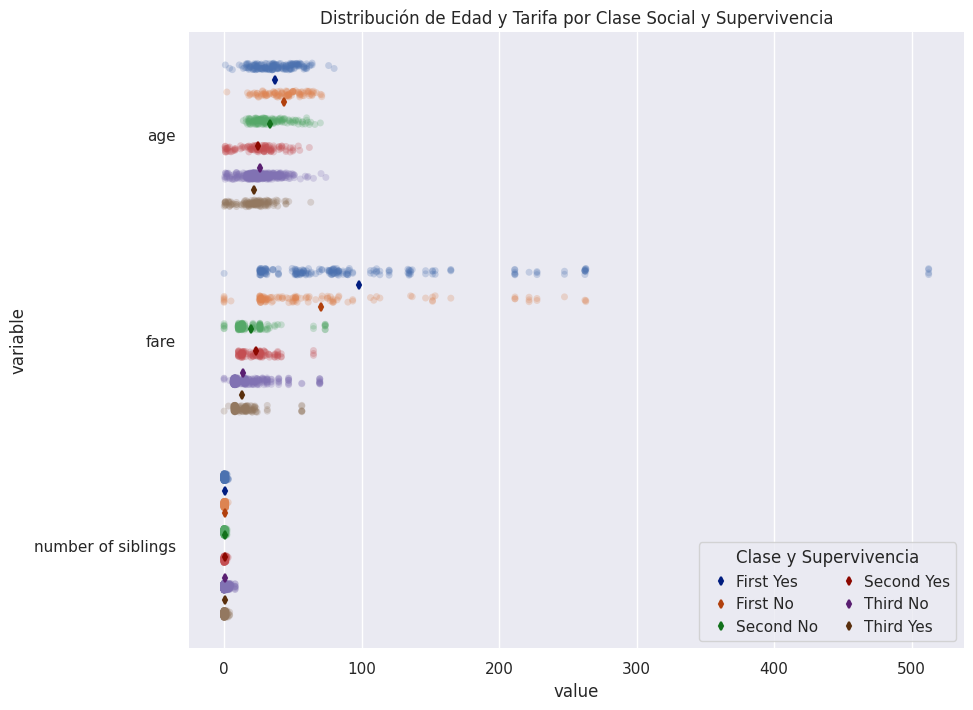

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas que queremos comparar
#en este caso edad, tarifa y numero de familiares en el mismo trayecto
titanic_num_vars = ['age', 'fare', 'number of siblings']

# "Derretimos" el DataFrame para Seaborn
df_titanic_melt = pd.melt(titanic_data, id_vars=['class'], value_vars=titanic_num_vars)

#Creación del gráfico
f, ax = plt.subplots(figsize=(10, 8))
sns.despine(bottom=True, left=True)

# Dibujamos los puntos
sns.stripplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=True, alpha=.25, zorder=1)

# Dibujamos el punto medio y el intervalo
sns.pointplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=.8 - .8 / 3, join=False, palette="dark",
              markers="d", scale=.75, ci=None)

# leyenda
handles, labels = ax.get_legend_handles_labels()
# En el Titanic hay 6 clases
# Por eso ajustamos el índice de la leyenda para que no se duplique
ax.legend(handles[6:], labels[6:], title="Clase y Supervivencia",
          handletextpad=0, columnspacing=1, loc="lower right", ncol=2, frameon=True)

plt.title("Distribución de Edad y Tarifa por Clase Social y Supervivencia")
plt.show()

# Cada puntito pequeño y semi-transparente es un pasajero real del Titanic
# El punto medio representa la Media (Promedio).
# La línea representa el intervalo y/o dispersión de datos

Exploración básica de los datos

In [8]:
#cargamos las columnas con datos más interesantes y de los cuales podemos deducir más información
data_columns = ['age','number of siblings','parch','cabin','fare']
titanic_data[data_columns].describe()
#count valores no nulos en esa columna

# mean (Media o Promedio) suma de todos los valores dividida por el número total de filas.

#  std qué tan dispersos están los datos respecto a la media.

# % -> cuartiles. Donde se encuentra el % de los datos


,age,number of siblings,parch,fare
count,1046.000,1309.000,1309.000,1308.000
mean,29.881,0.499,0.385,33.295
std,14.413,1.042,0.866,51.759
min,0.167,0.000,0.000,0.000
25%,21.000,0.000,0.000,7.896
50%,28.000,0.000,0.000,14.454
75%,39.000,1.000,0.000,31.275
max,80.000,8.000,9.000,512.329


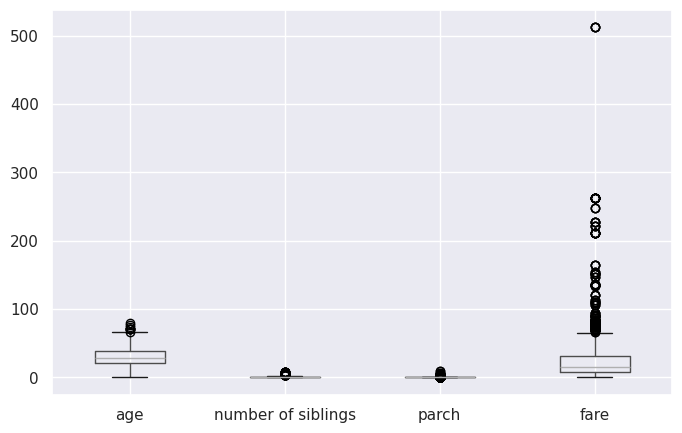

In [9]:
fig, ax = plt.subplots(figsize=(8,5));
titanic_data[data_columns].boxplot();

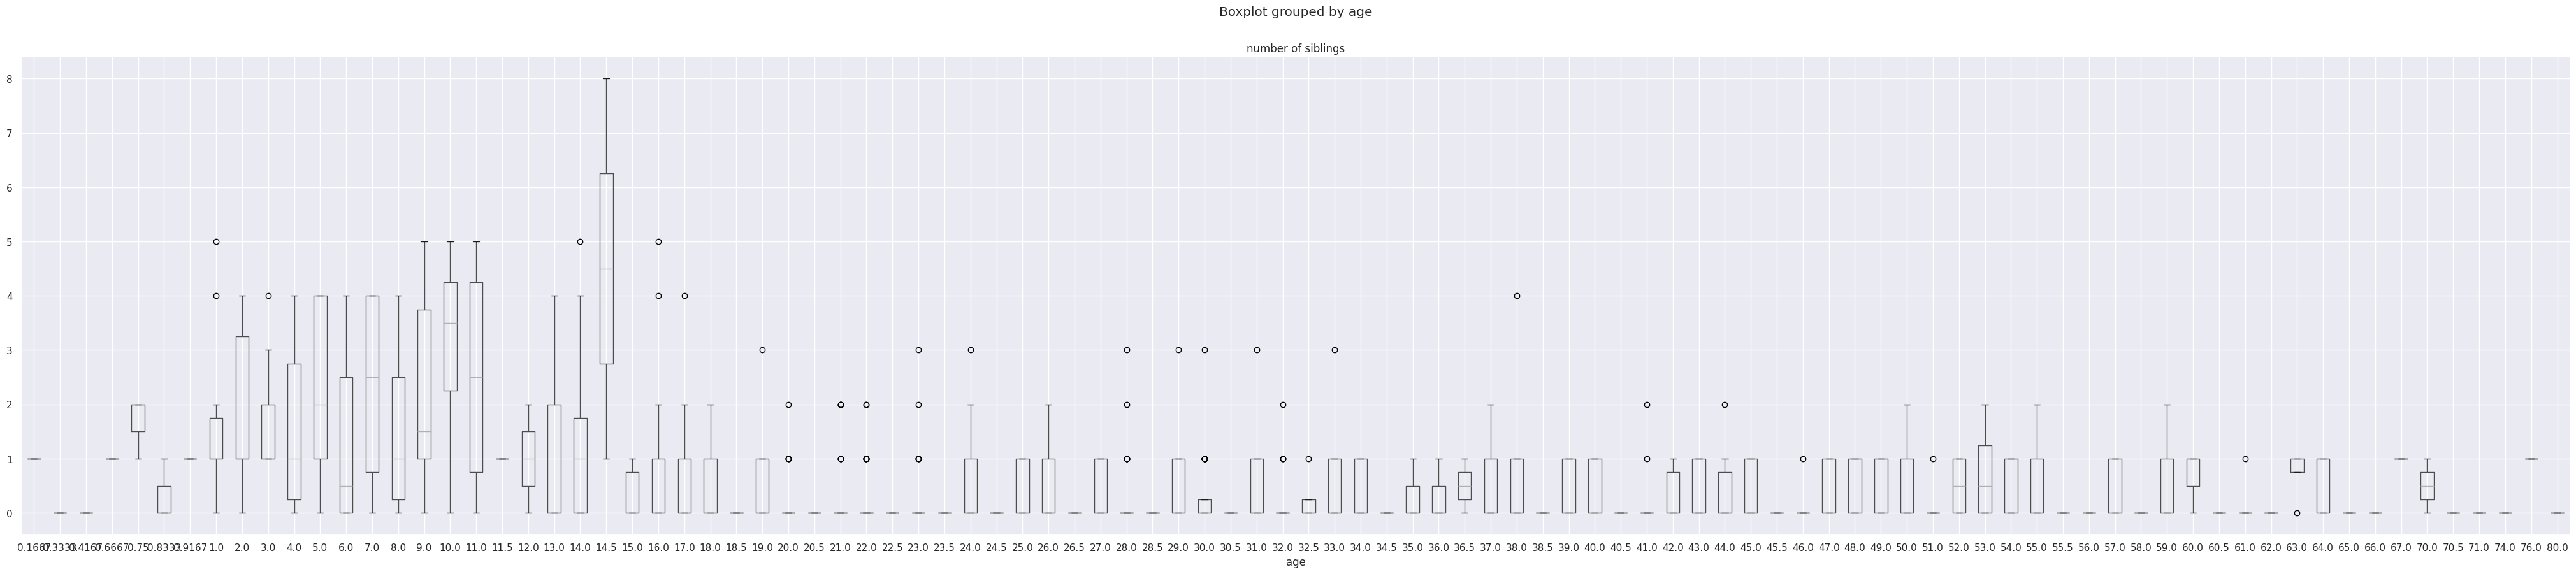

In [10]:
titanic_data.boxplot(column='number of siblings', by='age',figsize=(50,10));
#linea central - mediana
#caja - rango intercuartilico (del 25 al 75%)
#lineas fuera de la caja - valores atípicos

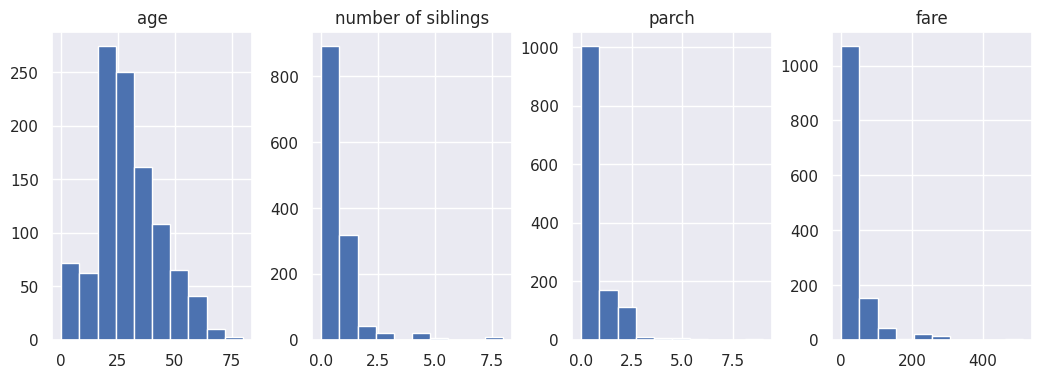

In [11]:
titanic_data[data_columns].hist(figsize=(16,4), layout=(1,5));
#representación simple de los números

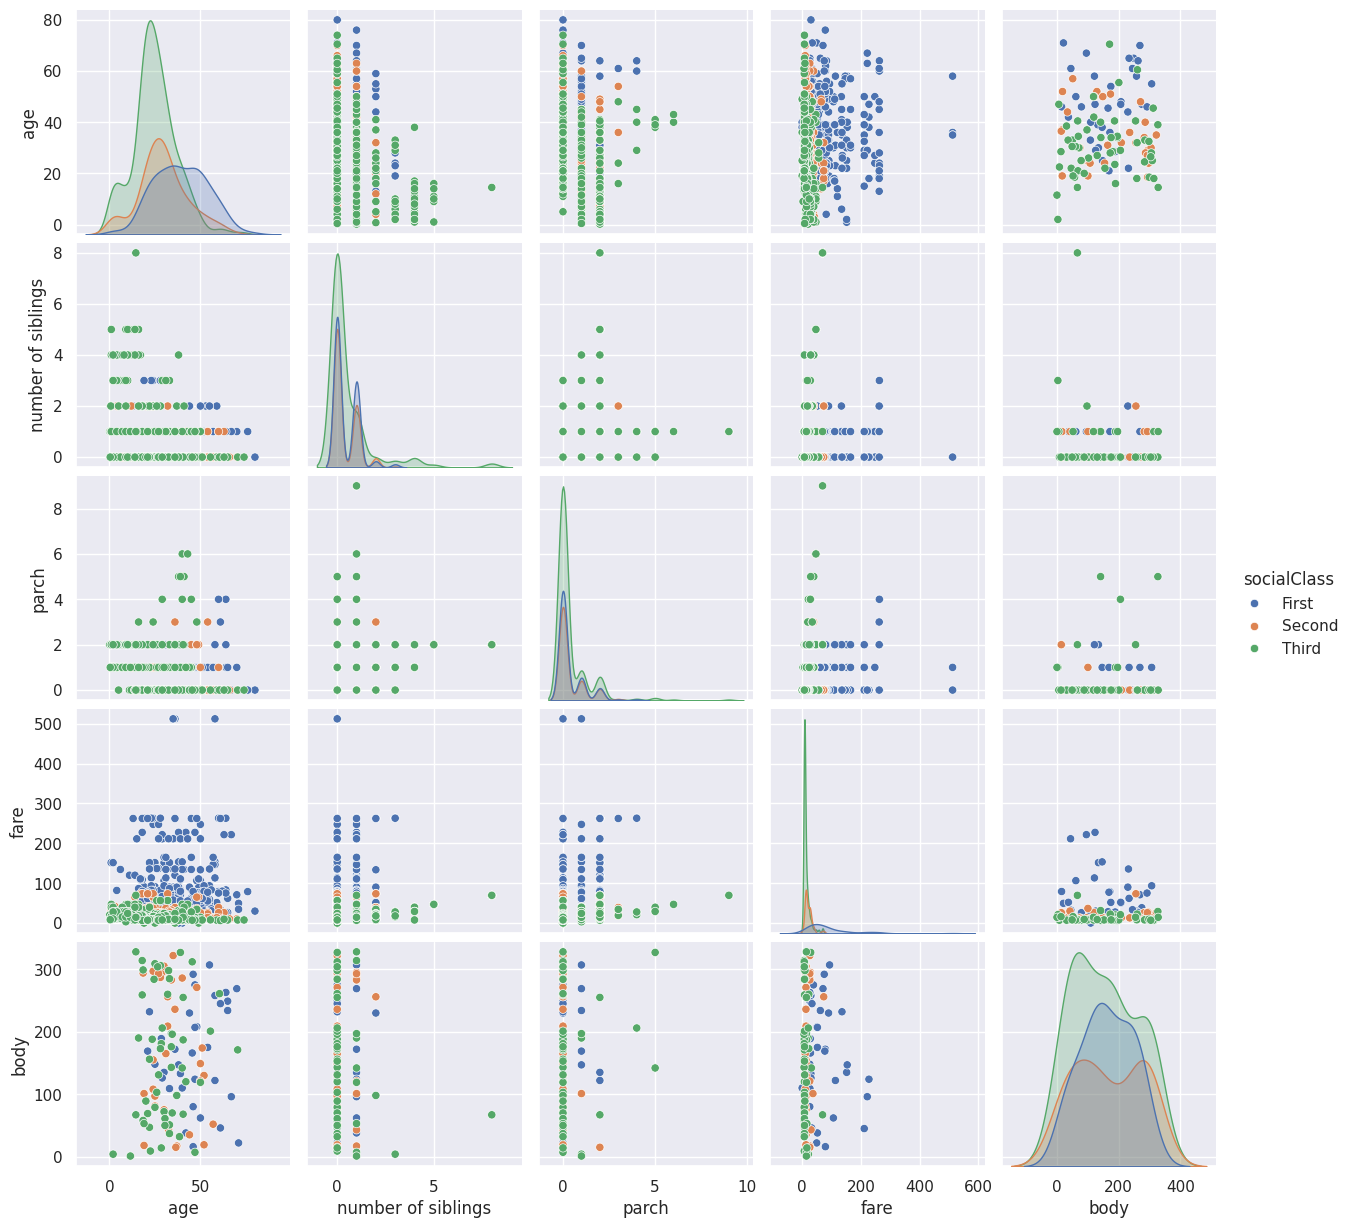

In [12]:
sns.pairplot(titanic_data, hue='socialClass');
# tenemos tres colores representando a cada clase social
# si por ejemplo dos colores están muy mezclados querrá decir que esas variables no son diferenciales para una representación

# En este caso las variables están bastante mezcladas. Hará falta un PCA

**1. Aplicar PCA**

In [13]:
#Aplicamos un PCA para mejorar al visualización de nuestros datos
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. Definimos la columna
data_columns = ['age', 'fare', 'number of siblings', 'parch']

# 2. Creamos la copia
# hace falta crear una limpieza de datos para eliminar los valores nulos. Otra opción sería generar los datos a partir de medias
titanic_clean = titanic_data.dropna(subset=data_columns).copy()
# y la transformamos
scaler = StandardScaler()
titanic_standarized = scaler.fit_transform(titanic_clean[data_columns])


# Procedemos a realizar el PCA :
#resta la media centrando los datos en 0
#divide por al desviacion estandar para que la dispersión sea 1


# 1. Definimos el PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(titanic_standarized)

# 3. Creamos un nuevo DataFrame con los resultados
df_pca = pd.DataFrame(data = pca_results, columns = ['PC1', 'PC2'])

# 4. Añadimos las etiquetas originales para colorear el gráfico después
df_pca['socialClass'] = titanic_clean['socialClass'].values
df_pca['survived'] = titanic_clean['survived'].values
df_pca['class'] = titanic_clean['class'].values
#df_pca['class'] = titanic_clean['class'].values

print(f"Pasajeros analizados tras limpiar nulos: {len(df_pca)}")
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
df_pca.head()

Pasajeros analizados tras limpiar nulos: 1045
Varianza explicada por cada componente: [0.39123158 0.29766425]


,PC1,PC2,socialClass,survived,class
0,0.260,2.198,First,Yes,First Yes
1,2.818,0.318,First,Yes,First Yes
2,2.792,0.369,First,No,First No
3,2.113,1.688,First,No,First No
4,2.234,1.452,First,No,First No


PCA de scikit-learn  <br>
-explained_variance_ratio_ (varianza por componente) <br>
una array que muestra el % de información en cada eje del PCA.<br>
PC1: si es muy alto, sobre el 65% significa que una sola combinación de las variables explica la mayor parte de las diferencias entre los pasajeros del tianic<br>
-explained_variance_ratio_.cumsum() (varianza acumulada) <br>
suma de los porcentajes anteriores. Ayuda a deducir cuantos porcentajes necesito para visualizar un modelo<br>
Conclusión: si proyectamos en un plano 2D usando únicamente PC1 y PC2 estamos conservando el 70% de la información original (después de la limpieza).

Si usamos 3D ganaríamos un 16% extra de precisión a cambio de una dimensión extra de complejidad

In [14]:
myPCA = PCA().fit(titanic_standarized)

print(myPCA.explained_variance_ratio_)
print(myPCA.explained_variance_ratio_.cumsum())

[0.39123158 0.29766425 0.15871333 0.15239084]
[0.39123158 0.68889583 0.84760916 1.        ]


In [15]:
# 1. Transformamos los datos y nos quedamos solo con las 2 primeras columnas ([:, :2])
datos_2d = myPCA.transform(titanic_standarized)[:, :2]

# 2. Lo pasamos a un DataFrame para que sea fácil de ver y usar
df_pca = pd.DataFrame(datos_2d, columns=['PC1', 'PC2'])

# Vemos el resultado
print(df_pca.head())

     PC1    PC2
0  0.260  2.198
1  2.818  0.318
2  2.792  0.369
3  2.113  1.688
4  2.234  1.452


**2. Gráfica de la varianza explicada por cada componente de PCA**

Text(0, 0.5, 'Valores Singulares')

Text(0.5, 0, 'Número de Componente Principal')

Text(0.5, 1.0, 'Gráfico de Sedimentación (Scree Plot) - Datos del Titanic')

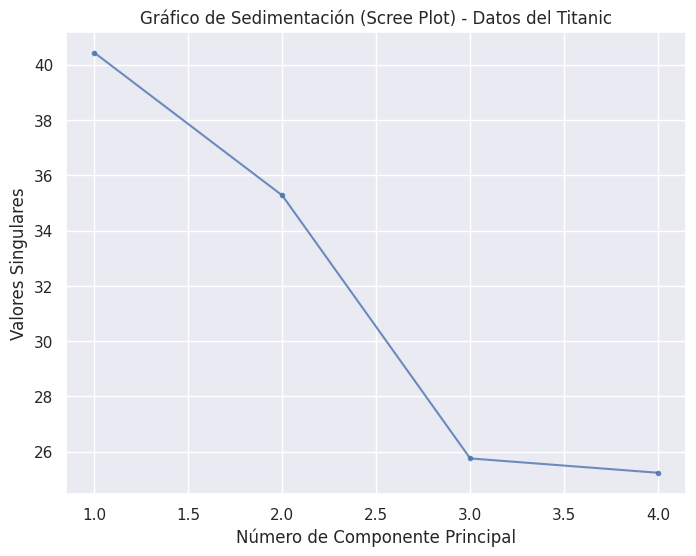

In [16]:
fig = plt.figure(figsize=(8,6))

plt.plot(range(1,len(myPCA.singular_values_)+1), myPCA.singular_values_, alpha=0.8, marker='.')

plt.ylabel('Valores Singulares') # Más preciso respecto al código
plt.xlabel('Número de Componente Principal') # Más descriptivo
plt.title('Gráfico de Sedimentación (Scree Plot) - Datos del Titanic') # Contextualizado

# plt.show() # (Opcional, pero buena práctica para mostrar el gráfico limpio al final)

# EJE X
#Como el PCA original tien 4 columnas originales, es igual a 4.

# range(1, 5) genera los números entre 1 y 4

# Al ponerlo en primer lugar, el programa sabe que es la X

Teníamos 4 datos diferentes de cada pasajero. Al usar esta técnic hemos logrado 'comprimir' esas 4 variables en solo 2. El gráfico nos demuestra que estas 2 nuevas variables conservan el 95% de la historia original. <br> <br>
Varianza explicada - linea azul
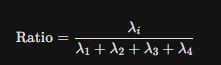<br>
Varianza explicada acumulativa - linea roja
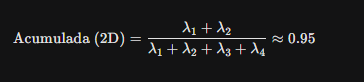

Lambda se consigue buscando un vector que al multiplicarlo por todos nuestros datos no cambie de dirección, solo de tamaño. Esa cantitdad es Lambda<br>
Matemáticamente usariamos la formula del determinante (c-lambda*I)=0

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Número de Componente Principal')

Text(0, 0.5, 'Proporción de Varianza Explicada')

Text(0.5, 1.0, 'Porcentaje de varianza explicada por componente')

([<matplotlib.axis.XTick at 0x7f93e9ac0050>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

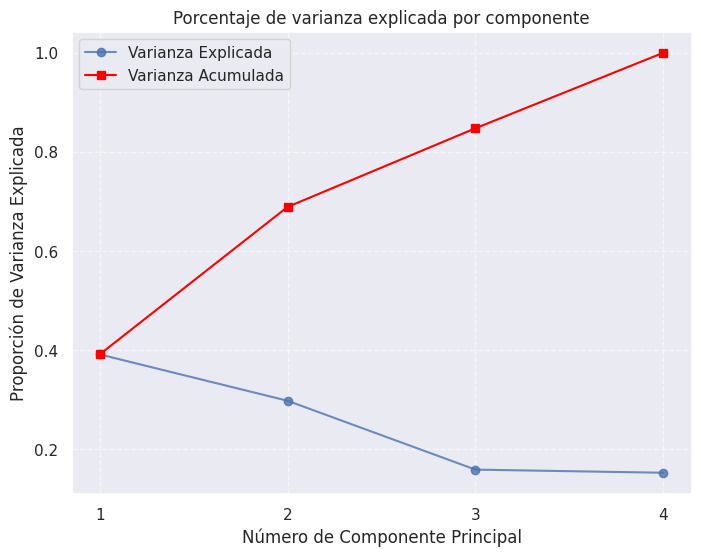

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Creamos una lista para el eje X (1, 2, 3, 4...)
componentes = range(1, len(myPCA.explained_variance_ratio_) + 1)

# 1. Graficamos la varianza individual
plt.plot(componentes, myPCA.explained_variance_ratio_,
         alpha=0.8, marker='o', label="Varianza Explicada")

# 2. Graficamos la varianza acumulada
plt.plot(componentes, np.cumsum(myPCA.explained_variance_ratio_),
         c='red', marker='s', label="Varianza Acumulada")

# Añadimos las etiquetas
plt.xlabel('Número de Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Porcentaje de varianza explicada por componente')

# Mejoras visuales: números enteros en el eje X, leyenda y cuadrícula
plt.xticks(componentes)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()



**3. Representar los pesos de los componentes**<br>Visualizamos el peso que asigna nuestro PCA a cada componente

<Figure size 1000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Peso de las variables originales en PC1 y PC2')

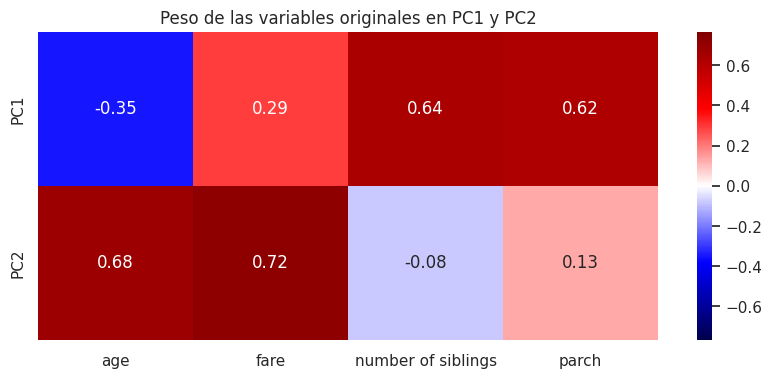

In [18]:
plt.figure(figsize=(10, 4))

# Añadimos [:2, :] para usar solo las dos primeras filas (PC1 y PC2)
sns.heatmap(myPCA.components_[:2, :],
            cmap='seismic',
            xticklabels=data_columns,
            yticklabels=['PC1', 'PC2'],
            vmin=-np.max(np.abs(myPCA.components_)),
            vmax=np.max(np.abs(myPCA.components_)),
            annot=True)

plt.title('Peso de las variables originales en PC1 y PC2')
plt.show()

**4. Visualizar los datos con PCA en 2/3D:**

Text(0.5, 1.0, 'Distribución de las Clases del Titanic en PC1 y PC2')

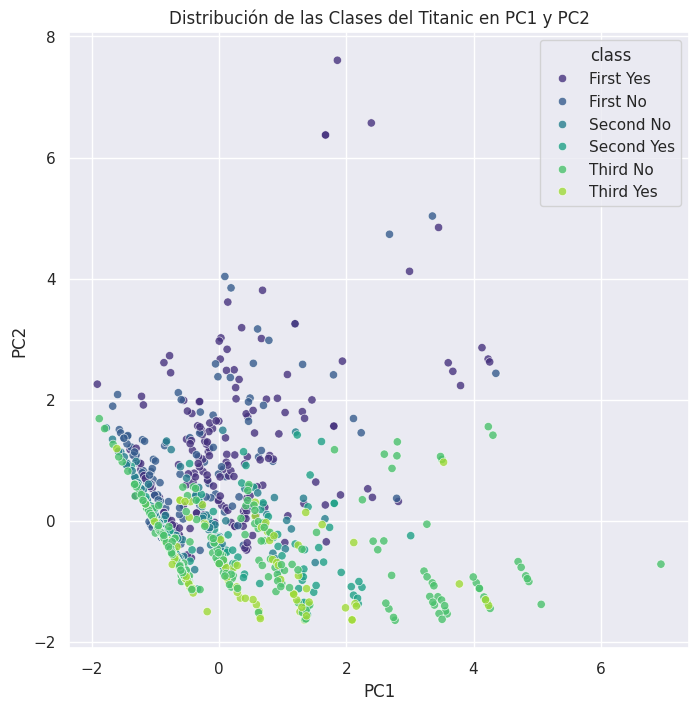

In [19]:
# 1. Transformamos directamente la matriz (ya tiene las 4 columnas exactas)
transformed_titanic = myPCA.transform(titanic_standarized)

# 2. Guardamos las nuevas componentes en el DataFrame original (que sí tiene la columna 'class')
titanic_clean['PC1'] = transformed_titanic[:, 0]
titanic_clean['PC2'] = transformed_titanic[:, 1]
titanic_clean['PC3'] = transformed_titanic[:, 2] # Lo guardamos por si quieres usar 3D luego

# 3. Dibujamos el gráfico usando titanic_clean
fig = plt.figure(figsize=(8,8))
_ = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='class', # Ahora sí encontrará esta columna
    data=titanic_clean,
    palette='viridis', # Opcional: una paleta bonita para diferenciar clases
    alpha=0.8
)

plt.title('Distribución de las Clases del Titanic en PC1 y PC2')
plt.show()

#Qué podemos deducir con este gráfico?
# La tercera y segunda clase es muy similar
# La primera clase tiene los puntos más dispares
# Tanto los yes como los no tienen repartidos por todo el gráfico sus valores

Text(0.5, 0, 'PC1')

Text(0.5, 0.5, 'PC2')

Text(0.5, 0, 'PC3')

Text(0.5, 0.92, 'Visualización 3D del Titanic (Matplotlib)')

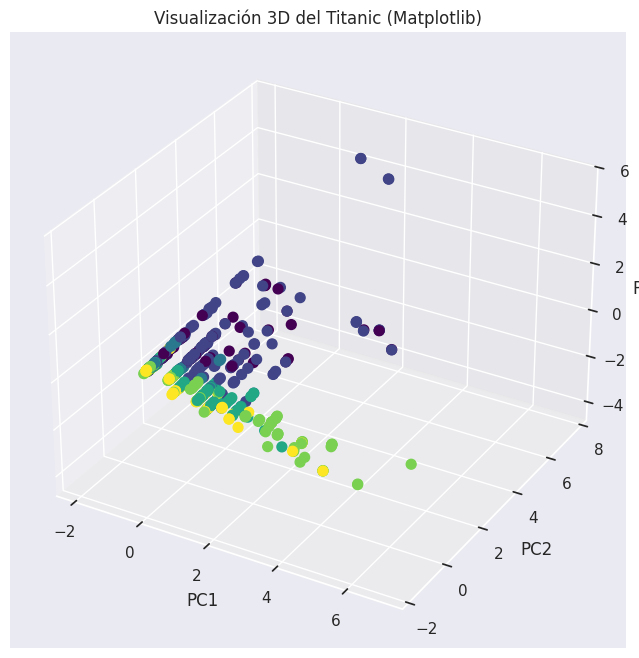

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Truco: Convertimos la columna 'class' a códigos automáticos (0, 1, 2...)
# Esto funciona perfectamente sean textos o números.
codigos_clase = pd.Categorical(titanic_clean['class']).codes

# Dibujamos los puntos
ax.scatter(
    titanic_clean['PC1'],
    titanic_clean['PC2'],
    titanic_clean['PC3'],
    depthshade=False,
    c=codigos_clase,   # Usamos los códigos que acabamos de generar
    cmap='viridis',    # Usamos una paleta de colores integrada (como 'viridis' o 'plasma')
    s=50
)

# Etiquetas
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Visualización 3D del Titanic (Matplotlib)')

plt.show()

In [21]:
import plotly.express as px

# Usamos directamente titanic_clean porque ya tiene PC1, PC2, PC3 y 'class'
fig = px.scatter_3d(
    titanic_clean,
    x='PC1',
    y='PC2',
    z='PC3',
    color='class', # Plotly elige paletas de colores muy buenas automáticamente
    title='Visualización 3D Interactiva del Titanic usando PCA',
    opacity=0.8    # Añadimos un poco de transparencia para ver los puntos solapados
)

# Hacemos los puntos un poco más precisos visualmente
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()

A partir de estas do gráficos tridimensionales, usando PC1, PC2, PC3, confirmamos visualmente lo que argumentamos en los pasos anteriores:<br>
- la Primera Clase se separa del resto.<br>
- la tercera dimensiónaporta un valor marginal para la segmentación.<br>
Confirmando que un análisis en 2D es suficiente para explicar la varianza principal de nuestros datos (95%).

**5. Aplicar LLE y visualizar los datos en 2/3D**

Resumen de datos tras MinMaxScaler:
     age  fare  number of siblings  parch
min  0.0   0.0                 0.0    0.0
max  1.0   1.0                 1.0    1.0
--------------------------------------------------
Error de reconstrucción LLE: -0.0000


<Axes: xlabel='LLE1', ylabel='LLE2'>

Text(0.5, 1.0, 'Visualización 2D del Titanic usando LLE (Locally Linear Embedding)')

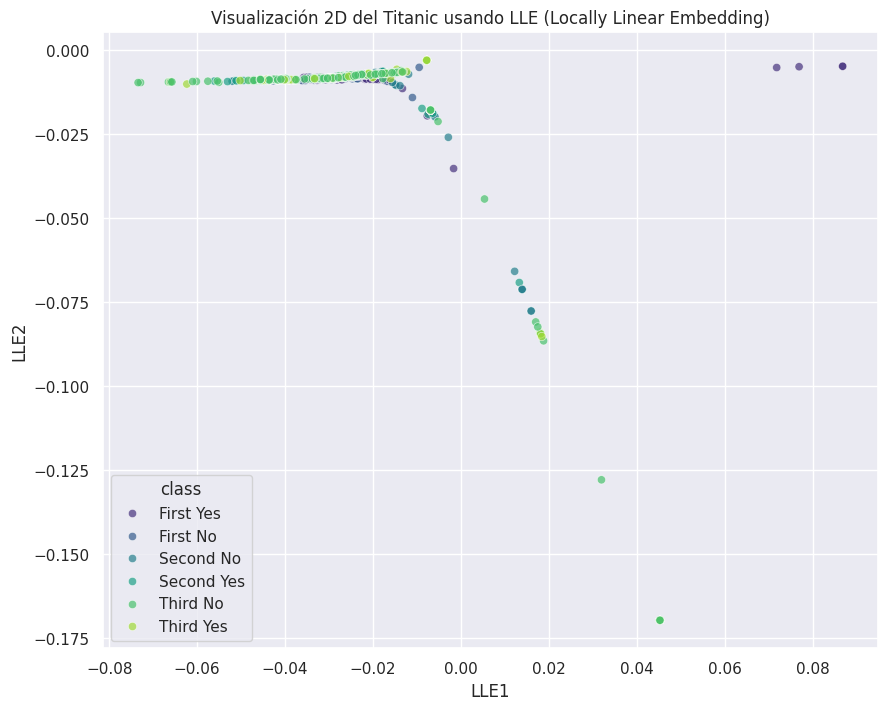

In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos una copia y escalamos los datos entre 0 y 1
titanic_min_max = titanic_clean.copy()
scaler_minmax = MinMaxScaler()
titanic_min_max[data_columns] = scaler_minmax.fit_transform(titanic_clean[data_columns])

# Vemos que ahora los valores de min son 0 y los max son 1
print("Resumen de datos tras MinMaxScaler:")
print(titanic_min_max[data_columns].describe().loc[['min', 'max']])
print("-" * 50)

# 2. Aplicamos el modelo LLE
# n_neighbors=15 es un buen punto de partida, pero puedes jugar con él (ej. 10 o 30)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
titanic_lle = lle.fit_transform(titanic_min_max[data_columns])

# 3. Vemos el error de reconstrucción (cuanto más bajo, mejor)
print(f'Error de reconstrucción LLE: {lle.reconstruction_error_:.4f}')

# 4. Guardamos las nuevas componentes LLE y graficamos
titanic_min_max[['LLE1', 'LLE2']] = titanic_lle

fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='LLE1',
    y='LLE2',
    hue='class',
    data=titanic_min_max,
    palette='viridis',
    alpha=0.7
)

plt.title('Visualización 2D del Titanic usando LLE (Locally Linear Embedding)')
plt.show()

Error de reconstrucción LLE (3D): 0.0000


Text(0.5, 0, 'LLE1')

Text(0.5, 0.5, 'LLE2')

Text(0.5, 0, 'LLE3')

Text(0.5, 0.92, 'Visualización 3D del Titanic usando LLE')

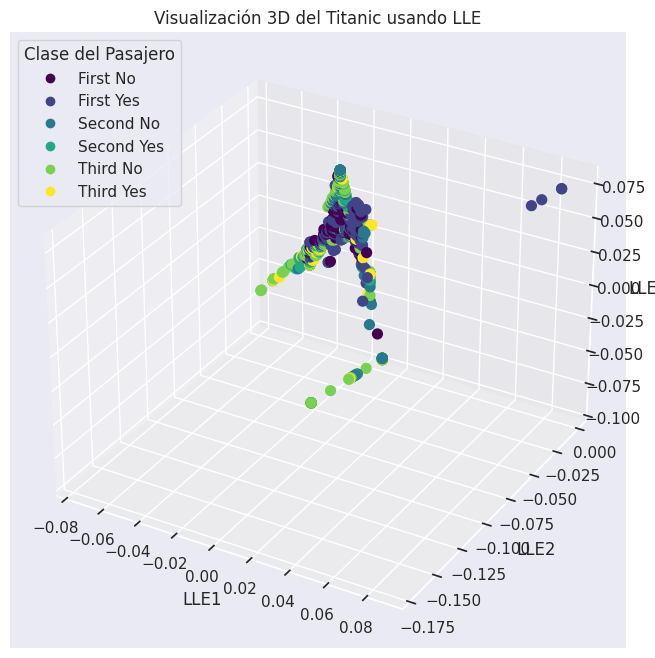

In [23]:
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
import pandas as pd

# 1. Configuramos el LLE para 3 Dimensiones
lle_3d = LocallyLinearEmbedding(n_components=3, n_neighbors=15, random_state=42)

# Entrenamos y transformamos los datos
titanic_lle_3d = lle_3d.fit_transform(titanic_min_max[data_columns])

# 2. Comprobamos si el error ha bajado al usar 3D
print(f'Error de reconstrucción LLE (3D): {lle_3d.reconstruction_error_:.4f}')

# 3. Guardamos las 3 nuevas coordenadas en tu tabla
titanic_min_max[['LLE1', 'LLE2', 'LLE3']] = titanic_lle_3d

# 4. Preparamos los colores de las clases (el truco que ya nos funcionó)
categoria_clase = pd.Categorical(titanic_min_max['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# 5. Creamos el Gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_min_max['LLE1'],
    titanic_min_max['LLE2'],
    titanic_min_max['LLE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# Añadimos la leyenda y etiquetas
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('LLE1')
ax.set_ylabel('LLE2')
ax.set_zlabel('LLE3')
plt.title('Visualización 3D del Titanic usando LLE')

plt.show()

In [24]:
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA

# 1. Calculamos PCA de 3 componentes (para el eje X, Y, Z)
# Recuerda: titanic_standarized ya contenía únicamente tus data_columns numéricas
pca_3d = PCA(n_components=3, random_state=42)
pca_features = pca_3d.fit_transform(titanic_standarized)

# 2. Creamos un DataFrame específico para este gráfico
df_pca_3d = pd.DataFrame(pca_features, columns=['PC1', 'PC2', 'PC3'])

# Añadimos la columna para el color (usamos .values para que cuadre a la perfección)
df_pca_3d['class'] = titanic_clean['class'].values

# 3. Graficamos usando Plotly
fig = px.scatter_3d(
    df_pca_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='class',
    title='Visualización 3D interactiva del Titanic usando PCA',
    opacity=0.8 # Un poco de transparencia para ver los puntos solapados
)

# Hacemos los puntos un poco más precisos (opcional pero recomendable)
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()

**6. Aplicar t-SNE y visualizar los datos en 2/3D**

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

Text(0.5, 1.0, 'Visualización 2D del Titanic usando t-SNE')

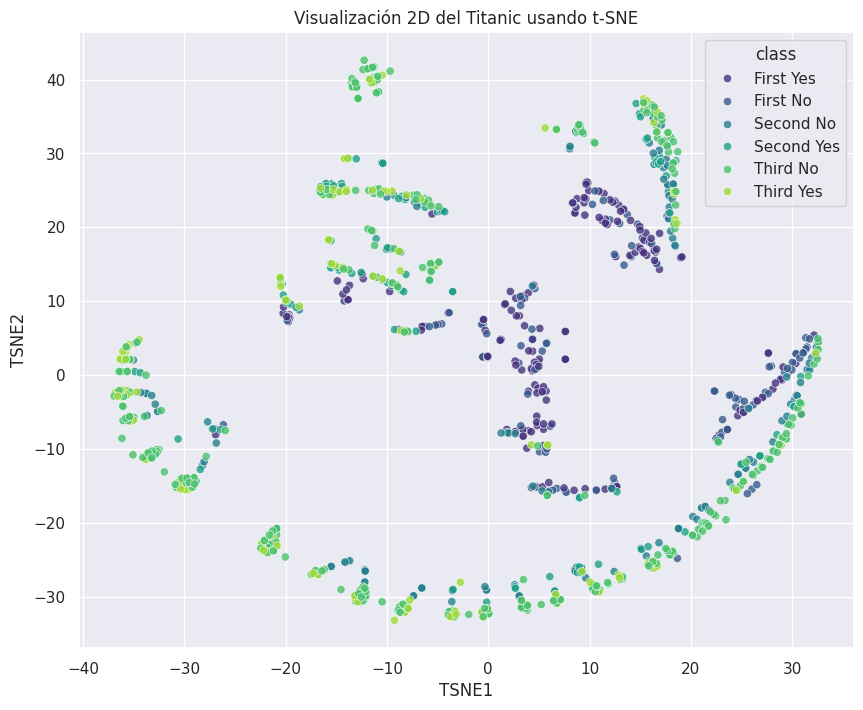

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos y entrenamos el algoritmo t-SNE (sin n_iter)
# Nota: t-SNE puede tardar unos segundos en ejecutarse porque requiere mucho cálculo
tsne = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# Transformamos los datos (usando la matriz estandarizada original)
titanic_tsne = tsne.fit_transform(titanic_standarized)

# 2. Guardamos las nuevas coordenadas en tu DataFrame limpio para poder graficarlas
titanic_clean[['TSNE1', 'TSNE2']] = titanic_tsne

# 3. Creamos el gráfico de dispersión
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='class',
    data=titanic_clean,
    palette='viridis', # Usamos la paleta de colores habitual
    alpha=0.8
)

plt.title('Visualización 2D del Titanic usando t-SNE')
plt.show()

Text(0.5, 0, 'TSNE1')

Text(0.5, 0.5, 'TSNE2')

Text(0.5, 0, 'TSNE3')

Text(0.5, 0.92, 'Visualización 3D del Titanic usando t-SNE')

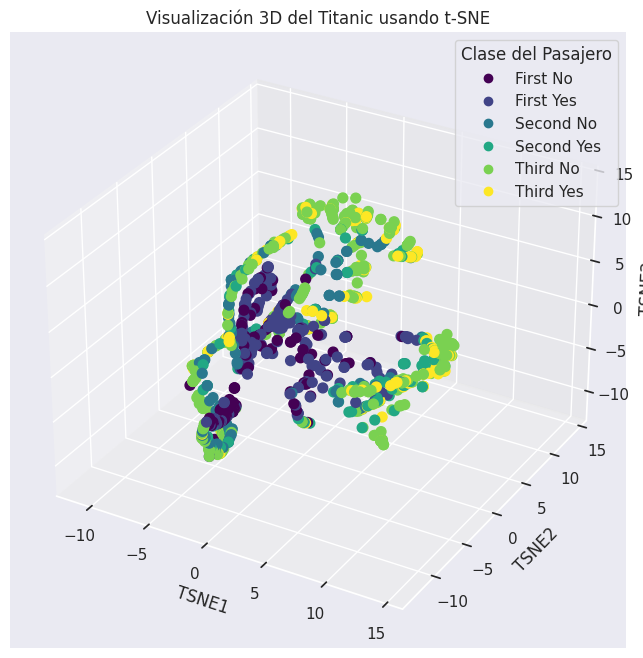

In [29]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 1. Definimos y entrenamos t-SNE para 3 Dimensiones (quitamos n_iter)
tsne_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)

# Transformamos los datos estandarizados
titanic_tsne_3d = tsne_3d.fit_transform(titanic_standarized)

# 2. Guardamos las 3 nuevas coordenadas en tu DataFrame limpio
titanic_clean[['TSNE1', 'TSNE2', 'TSNE3']] = titanic_tsne_3d

# 3. Preparamos los colores y la leyenda (truco automático)
categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# 4. Creamos el Gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1'],
    titanic_clean['TSNE2'],
    titanic_clean['TSNE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# Añadimos la leyenda y etiquetas
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')
plt.title('Visualización 3D del Titanic usando t-SNE')

plt.show()

In [30]:
import plotly.express as px

# Usamos directamente titanic_clean porque ya tiene TSNE1, TSNE2, TSNE3 y 'class'
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='class',
    title='Visualización 3D interactiva del Titanic usando t-SNE',
    opacity=0.8 # Transparencia para ver a través de las "islas" de puntos
)

# Hacemos los puntos un poco más pequeños para distinguir mejor los grupos
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()

Datos entre 0 y 1

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Usando escalado MinMaxScaler 0-1)')

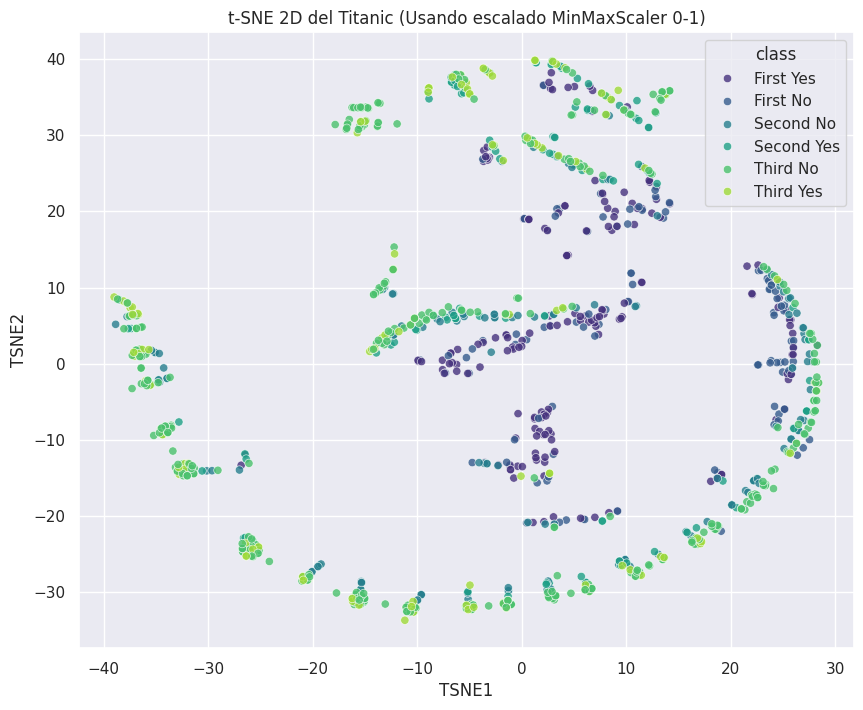

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entrenamos t-SNE (sin n_iter para evitar el error)
tsne_minmax = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# IMPORTANTE: Aquí le pasamos titanic_min_max en lugar de titanic_standarized
titanic_tsne_minmax = tsne_minmax.fit_transform(titanic_min_max[data_columns])

# 2. Guardamos las nuevas coordenadas en la tabla min_max
titanic_min_max[['TSNE1', 'TSNE2']] = titanic_tsne_minmax

# 3. Dibujamos el gráfico
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='class',
    data=titanic_min_max,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Usando escalado MinMaxScaler 0-1)')
plt.show()

Text(0.5, 0, 'TSNE1')

Text(0.5, 0.5, 'TSNE2')

Text(0.5, 0, 'TSNE3')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con MinMaxScaler)')

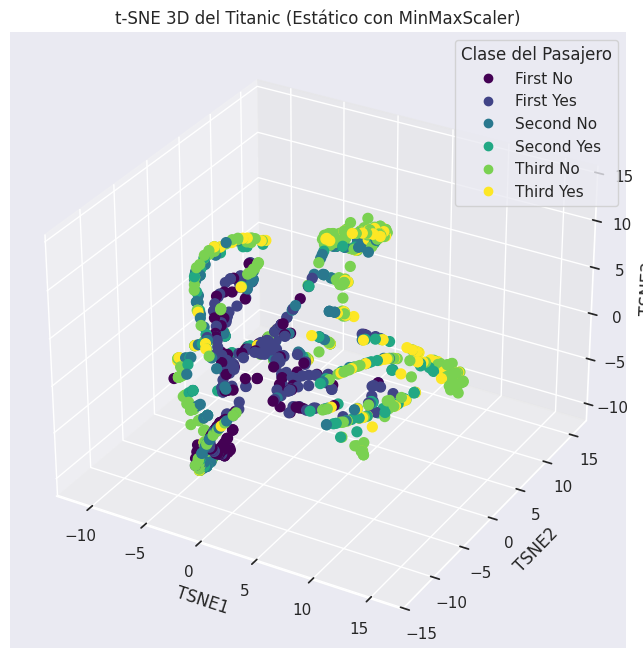

In [32]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 1. Entrenamos t-SNE para 3 componentes (3 Dimensiones)
tsne_minmax_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)

# Transformamos los datos que ya teníamos aplastados entre 0 y 1
titanic_tsne_minmax_3d = tsne_minmax_3d.fit_transform(titanic_min_max[data_columns])

# 2. Guardamos las 3 coordenadas en la tabla min_max
titanic_min_max[['TSNE1', 'TSNE2', 'TSNE3']] = titanic_tsne_minmax_3d

# 3. Preparamos los colores automáticos para la leyenda
categoria_clase = pd.Categorical(titanic_min_max['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# 4. Creamos el Gráfico 3D estático
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_min_max['TSNE1'],
    titanic_min_max['TSNE2'],
    titanic_min_max['TSNE3'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# Añadimos la leyenda y las etiquetas de los ejes
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')
plt.title('t-SNE 3D del Titanic (Estático con MinMaxScaler)')

plt.show()

In [33]:
import plotly.express as px

# Usamos la misma tabla titanic_min_max que ya contiene las nuevas coordenadas 3D
fig = px.scatter_3d(
    titanic_min_max,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con MinMaxScaler)',
    opacity=0.8 # Un poco de transparencia para no ocultar puntos
)

# Hacemos los puntos más precisos para ver bien las "islas"
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()

Standard scaler (distancias)

<Axes: xlabel='TSNE1_std', ylabel='TSNE2_std'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Usando StandardScaler)')

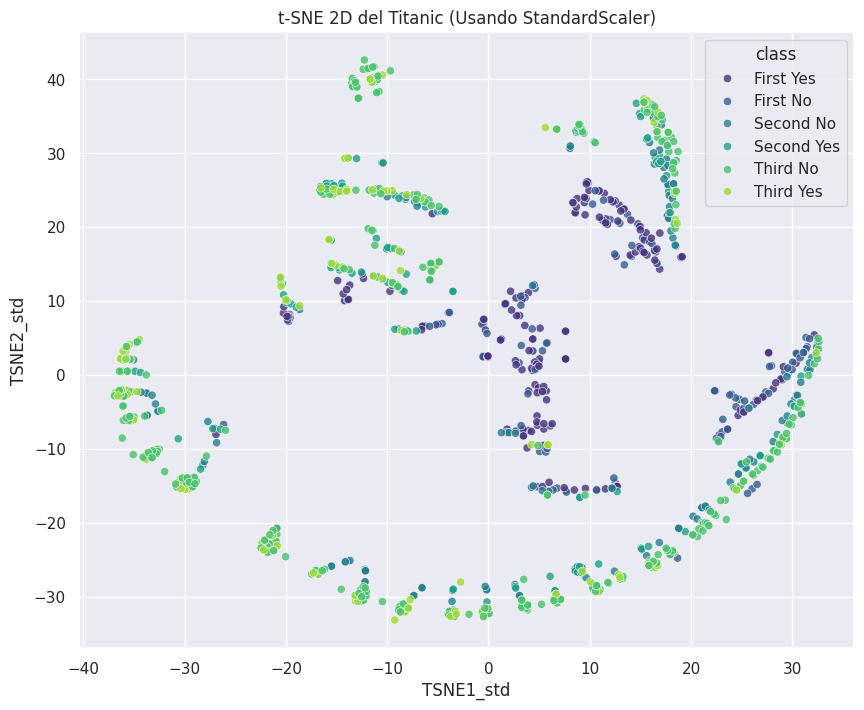

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entrenamos t-SNE en 2 dimensiones
tsne_std_2d = TSNE(n_components=2, perplexity=30, init='random', random_state=42)

# 2. Transformamos usando la matriz ESTANDARIZADA (StandardScaler)
titanic_tsne_std_2d = tsne_std_2d.fit_transform(titanic_standarized)

# 3. Guardamos las nuevas coordenadas en tu tabla limpia
titanic_clean[['TSNE1_std', 'TSNE2_std']] = titanic_tsne_std_2d

# 4. Dibujamos el gráfico
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1_std',
    y='TSNE2_std',
    hue='class',
    data=titanic_clean,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Usando StandardScaler)')
plt.show()

Text(0.5, 0, 'TSNE1_std')

Text(0.5, 0.5, 'TSNE2_std')

Text(0.5, 0, 'TSNE3_std')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con StandardScaler)')

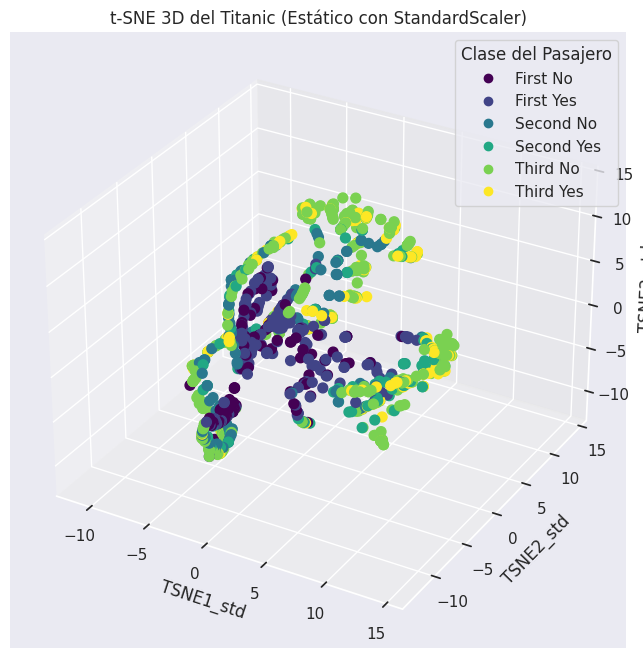

In [35]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 1. Entrenamos t-SNE para 3 Dimensiones
tsne_std_3d = TSNE(n_components=3, perplexity=30, init='random', random_state=42)

# Transformamos usando la matriz ESTANDARIZADA
titanic_tsne_std_3d = tsne_std_3d.fit_transform(titanic_standarized)

# 2. Guardamos las coordenadas 3D en la tabla
titanic_clean[['TSNE1_std_3D', 'TSNE2_std_3D', 'TSNE3_std_3D']] = titanic_tsne_std_3d

# 3. Preparamos los colores y nombres (Nuestro truco automático)
categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# 4. Creamos el Gráfico 3D Estático
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1_std_3D'],
    titanic_clean['TSNE2_std_3D'],
    titanic_clean['TSNE3_std_3D'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# Añadimos leyenda y etiquetas
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1_std')
ax.set_ylabel('TSNE2_std')
ax.set_zlabel('TSNE3_std')
plt.title('t-SNE 3D del Titanic (Estático con StandardScaler)')

plt.show()

In [36]:
import plotly.express as px

# Usamos titanic_clean que ya tiene las 3 nuevas coordenadas que acabamos de crear
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1_std_3D',
    y='TSNE2_std_3D',
    z='TSNE3_std_3D',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con StandardScaler)',
    opacity=0.8
)

# Hacemos los puntos más precisos
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()

Con PCA

<Axes: xlabel='TSNE1_pca', ylabel='TSNE2_pca'>

Text(0.5, 1.0, 't-SNE 2D del Titanic (Inicialización con PCA)')

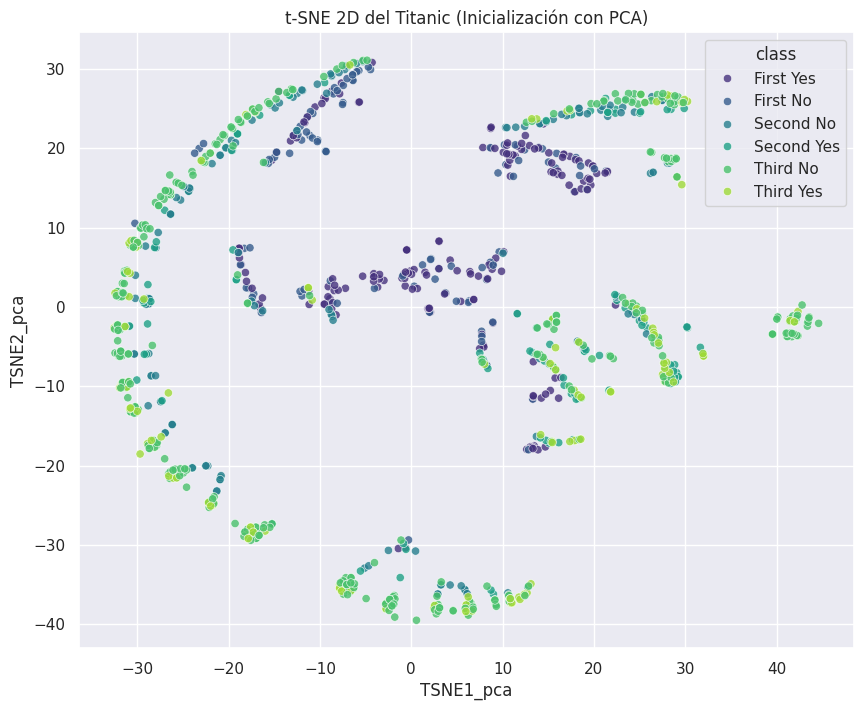

In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entrenamos t-SNE usando init='pca' (la mejor práctica)
# Mantenemos perplexity=30 y quitamos n_iter por compatibilidad
tsne_pca_2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)

# 2. Transformamos los datos estandarizados
titanic_tsne_pca_2d = tsne_pca_2d.fit_transform(titanic_standarized)

# 3. Guardamos las coordenadas en tu DataFrame limpio
titanic_clean[['TSNE1_pca', 'TSNE
2_pca']] = titanic_tsne_pca_2d

# 4. Dibujamos el gráfico
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1_pca',
    y='TSNE2_pca',
    hue='class',
    data=titanic_clean,
    palette='viridis',
    alpha=0.8
)

plt.title('t-SNE 2D del Titanic (Inicialización con PCA)')
plt.show()

Text(0.5, 0, 'TSNE1_pca')

Text(0.5, 0.5, 'TSNE2_pca')

Text(0.5, 0, 'TSNE3_pca')

Text(0.5, 0.92, 't-SNE 3D del Titanic (Estático con init=PCA)')

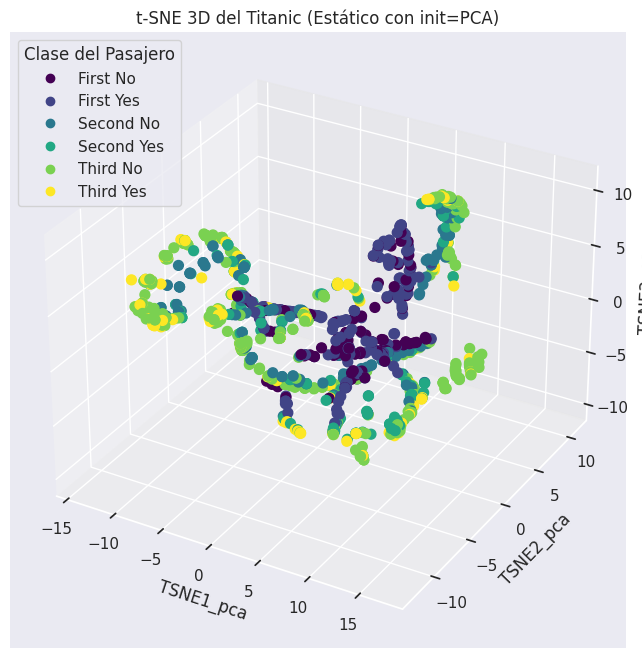

In [38]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# 1. Entrenamos t-SNE para 3 Dimensiones con init='pca'
tsne_pca_3d = TSNE(n_components=3, perplexity=30, init='pca', random_state=42)

# Transformamos los datos
titanic_tsne_pca_3d = tsne_pca_3d.fit_transform(titanic_standarized)

# 2. Guardamos las 3 coordenadas en la tabla
titanic_clean[['TSNE1_pca_3D', 'TSNE2_pca_3D', 'TSNE3_pca_3D']] = titanic_tsne_pca_3d

# 3. Preparamos los colores (nuestro truco automático)
categoria_clase = pd.Categorical(titanic_clean['class'])
codigos_clase = categoria_clase.codes
nombres_clase = categoria_clase.categories

# 4. Creamos el Gráfico 3D Estático
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    titanic_clean['TSNE1_pca_3D'],
    titanic_clean['TSNE2_pca_3D'],
    titanic_clean['TSNE3_pca_3D'],
    depthshade=False,
    c=codigos_clase,
    cmap='viridis',
    s=50
)

# Añadimos leyenda y etiquetas
handles, _ = scatter.legend_elements()
ax.legend(handles, nombres_clase, title="Clase del Pasajero")

ax.set_xlabel('TSNE1_pca')
ax.set_ylabel('TSNE2_pca')
ax.set_zlabel('TSNE3_pca')
plt.title('t-SNE 3D del Titanic (Estático con init=PCA)')

plt.show()

In [39]:
import plotly.express as px

# Usamos titanic_clean con las nuevas coordenadas generadas por el modelo PCA+TSNE
fig = px.scatter_3d(
    titanic_clean,
    x='TSNE1_pca_3D',
    y='TSNE2_pca_3D',
    z='TSNE3_pca_3D',
    color='class',
    title='t-SNE 3D Interactivo del Titanic (Plotly con init=PCA)',
    opacity=0.8
)

# Hacemos los puntos más precisos
fig.update_traces(marker=dict(size=4))

# Mostramos el gráfico interactivo
fig.show()